# MrBeast YouTube Performance Analysis

**Dataset:** 981 videos from MrBeast's main channel, fetched via YouTube Data API v3  
**Goal:** Analyze career-wide performance patterns — what content drives views, how strategy evolved, and what title/format signals predict success.

---

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
RED, BLUE, GREEN, ORANGE = '#E53935', '#1E88E5', '#43A047', '#FB8C00'

df = pd.read_csv('data/processed/mrbeast_metrics.csv')
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)
df = df.sort_values('published_at').reset_index(drop=True)

print(f'Videos loaded: {len(df)}')
print(f'Date range: {df["published_at"].min().date()} → {df["published_at"].max().date()}')

Videos loaded: 981
Date range: 2012-02-20 → 2026-05-19


In [2]:
# helper: parse ISO 8601 duration to seconds
def parse_sec(s):
    h = re.search(r'(\d+)H', s)
    m = re.search(r'(\d+)M', s)
    sec = re.search(r'(\d+)S', s)
    return (int(h.group(1))*3600 if h else 0) + \
           (int(m.group(1))*60  if m else 0) + \
           (int(sec.group(1))   if sec else 0)

df['duration_sec'] = df['duration'].apply(parse_sec)
df['is_short'] = df['duration_sec'] < 120
df['quarter'] = df['published_at'].dt.to_period('Q').dt.to_timestamp()

df[['title','view_count','views_per_day','engagement_rate','duration_sec']].describe().round(2)

,view_count,views_per_day,engagement_rate,duration_sec
count,9.810000e+02,981.00,973.00,981.00
mean,1.258097e+08,449159.65,0.03,930.39
std,2.108369e+08,2360415.29,0.02,5637.95
min,6.420100e+04,14.72,0.00,2.00
25%,1.599180e+05,37.93,0.02,110.00
50%,1.818256e+07,6791.38,0.03,235.00
75%,1.810302e+08,278635.86,0.04,744.00
max,1.771355e+09,48289562.50,0.23,85687.00


## 1. Recent Performance

Looking at the most recent videos: which ones spread fastest (views per day) and which drove the most community interaction (engagement rate).

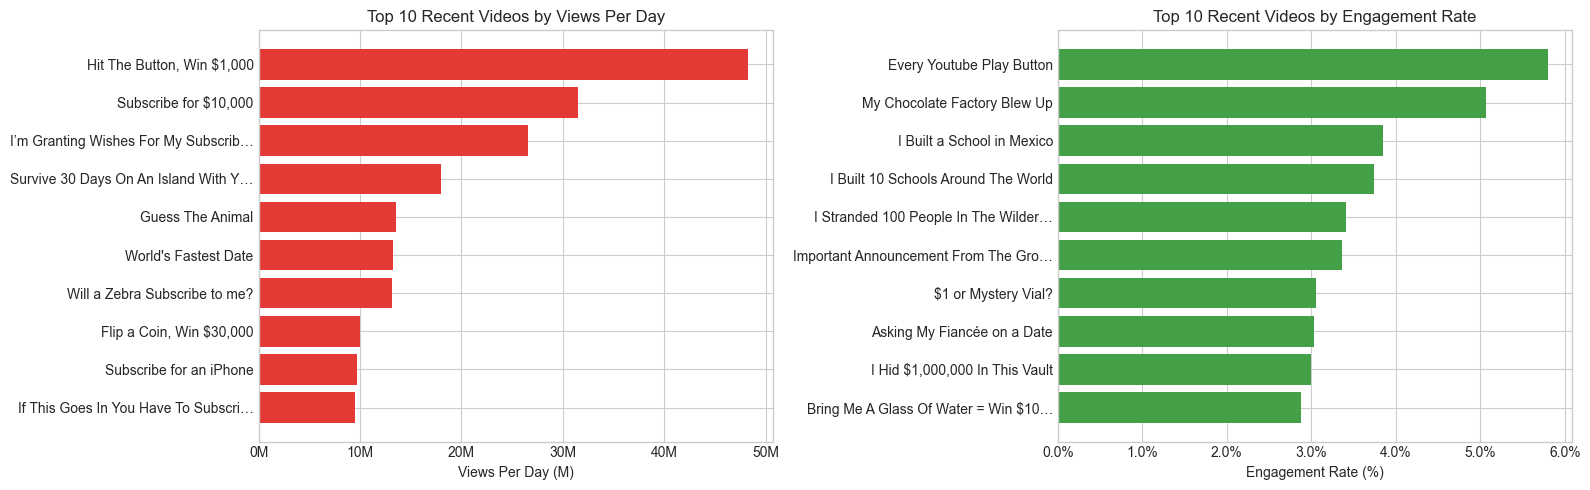

In [3]:
recent = df.sort_values('published_at').tail(50)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 by views per day
ax = axes[0]
top_vpd = recent.nlargest(10, 'views_per_day').sort_values('views_per_day')
labels = [t[:35] + '…' if len(t) > 35 else t for t in top_vpd['title']]
ax.barh(labels, top_vpd['views_per_day'] / 1e6, color=RED)
ax.set_xlabel('Views Per Day (M)')
ax.set_title('Top 10 Recent Videos by Views Per Day')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Top 10 by engagement rate
ax = axes[1]
top_eng = recent.nlargest(10, 'engagement_rate').sort_values('engagement_rate')
labels = [t[:35] + '…' if len(t) > 35 else t for t in top_eng['title']]
ax.barh(labels, top_eng['engagement_rate'] * 100, color=GREEN)
ax.set_xlabel('Engagement Rate (%)')
ax.set_title('Top 10 Recent Videos by Engagement Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

## 2. Short-form vs Long-form

MrBeast has increasingly shifted toward short-form content. Does format affect performance?

In [4]:
grp = df.groupby('is_short').agg(
    count=('video_id', 'count'),
    avg_views=('view_count', 'mean'),
    avg_vpd=('views_per_day', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).rename(index={True: 'Short-form (<2 min)', False: 'Long-form (≥2 min)'})

grp['avg_views'] = (grp['avg_views'] / 1e6).round(1)
grp['avg_vpd'] = (grp['avg_vpd'] / 1e6).round(2)
grp['avg_engagement'] = (grp['avg_engagement'] * 100).round(2)
grp.columns = ['# Videos', 'Avg Views (M)', 'Avg Views/Day (M)', 'Avg Engagement (%)']
grp

,# Videos,Avg Views (M),Avg Views/Day (M),Avg Engagement (%)
is_short,,,,
Long-form (≥2 min),726,72.5,0.12,3.03
Short-form (<2 min),255,277.7,1.39,2.86


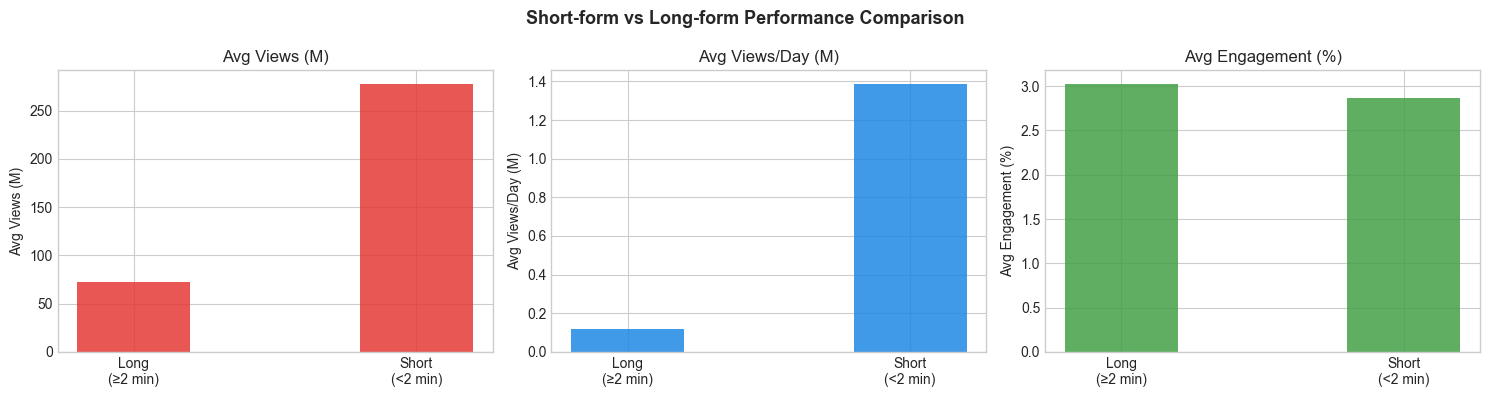

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('avg_views', 'Avg Views (M)', RED),
           ('avg_vpd',   'Avg Views/Day (M)', BLUE),
           ('avg_engagement', 'Avg Engagement (%)', GREEN)]

grp_raw = df.groupby('is_short').agg(
    avg_views=('view_count', 'mean'),
    avg_vpd=('views_per_day', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).rename(index={True: 'Short\n(<2 min)', False: 'Long\n(≥2 min)'})

for ax, (col, ylabel, color) in zip(axes, metrics):
    vals = grp_raw[col]
    if 'engagement' not in col:
        vals = vals / 1e6
    else:
        vals = vals * 100
    ax.bar(vals.index, vals.values, color=color, alpha=0.85, width=0.4)
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)

plt.suptitle('Short-form vs Long-form Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Short-form videos spread faster (higher views/day) but long-form drives higher engagement. This reflects a classic reach vs. depth trade-off in creator strategy.

## 3. Career Trajectory

MrBeast started in 2012. When did growth inflect, and how has average performance changed?

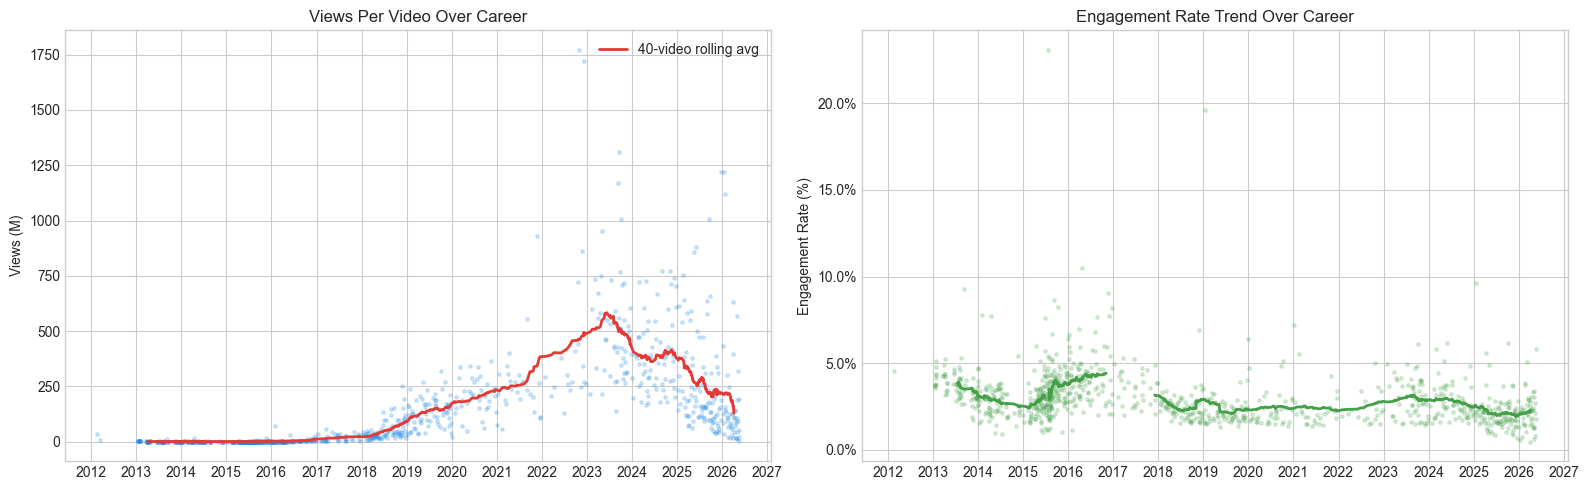

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Views per video scatter + rolling avg
ax = axes[0]
ax.scatter(df['published_at'], df['view_count'] / 1e6, alpha=0.2, s=6, color=BLUE)
roll = df['view_count'].rolling(40, center=True).mean()
ax.plot(df['published_at'], roll / 1e6, color=RED, linewidth=2, label='40-video rolling avg')
ax.set_ylabel('Views (M)')
ax.set_title('Views Per Video Over Career')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()

# Engagement rate over career
ax = axes[1]
ax.scatter(df['published_at'], df['engagement_rate'] * 100, alpha=0.2, s=6, color=GREEN)
roll_eng = df['engagement_rate'].rolling(40, center=True).mean() * 100
ax.plot(df['published_at'], roll_eng, color=GREEN, linewidth=2)
ax.set_ylabel('Engagement Rate (%)')
ax.set_title('Engagement Rate Trend Over Career')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

## 4. Content Strategy Evolution

How has video length changed, and how often does MrBeast upload?

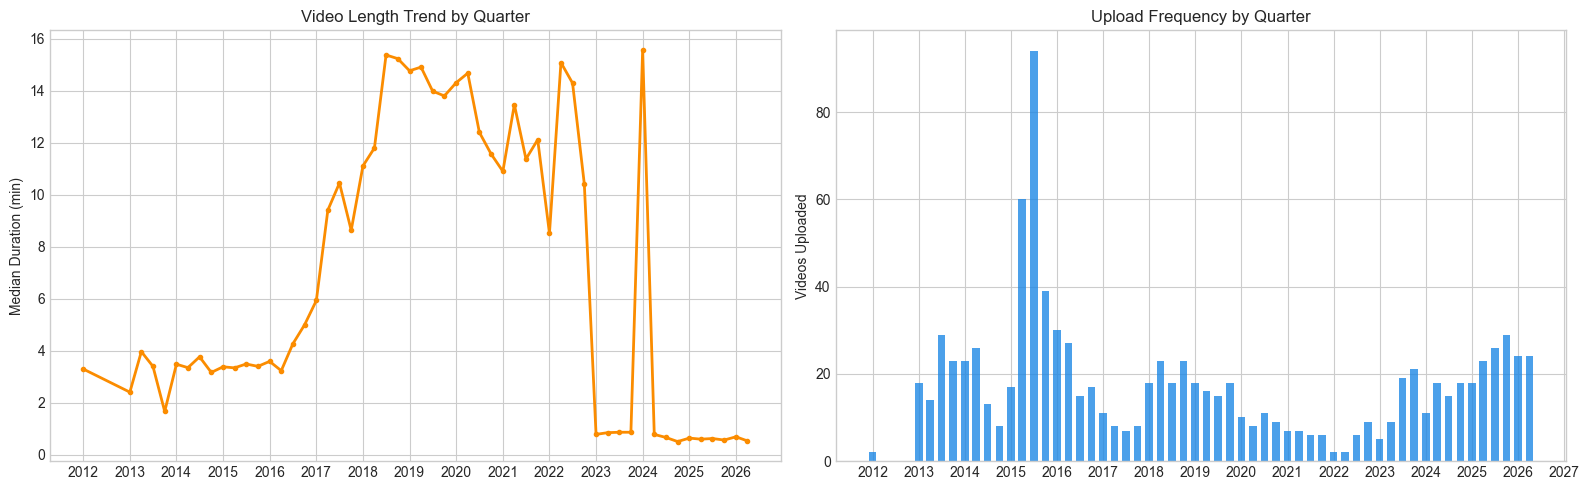

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Duration trend
ax = axes[0]
dur_q = df.groupby('quarter')['duration_sec'].median() / 60
ax.plot(dur_q.index, dur_q.values, color=ORANGE, marker='o', markersize=3, linewidth=2)
ax.set_ylabel('Median Duration (min)')
ax.set_title('Video Length Trend by Quarter')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

# Upload frequency
ax = axes[1]
freq_q = df.groupby('quarter').size()
ax.bar(freq_q.index, freq_q.values, width=60, color=BLUE, alpha=0.8)
ax.set_ylabel('Videos Uploaded')
ax.set_title('Upload Frequency by Quarter')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

## 5. What Content Performs Best?

Classifying videos by content type and checking which title keywords predict higher average views.

In [8]:
CATEGORIES = {
    'Subscribe Bait': r'\bsubscribe\b',
    'Survive/Stranded': r'surviv|strand|island|wilderness',
    'Last To': r'last to',
    'Guess Challenge': r'\bguess\b',
    'Vs/Race': r'\bvs\b|\bracer?d?\b',
    'Win $': r'win \$|,000',
}

def categorize(title):
    t = title.lower()
    for label, pat in CATEGORIES.items():
        if re.search(pat, t):
            return label
    return 'Other'

df['category'] = df['title'].apply(categorize)

cat_stats = df.groupby('category').agg(
    count=('video_id', 'count'),
    avg_views=('view_count', 'mean'),
    avg_engagement=('engagement_rate', 'mean')
).sort_values('avg_views', ascending=False)
cat_stats['avg_views_M'] = (cat_stats['avg_views'] / 1e6).round(1)
cat_stats['avg_engagement_%'] = (cat_stats['avg_engagement'] * 100).round(2)
cat_stats[['count', 'avg_views_M', 'avg_engagement_%']]

,count,avg_views_M,avg_engagement_%
category,,,
Subscribe Bait,11,441.4,2.65
Guess Challenge,7,395.7,1.87
Vs/Race,54,257.1,2.35
Survive/Stranded,35,241.9,2.10
Win $,166,200.0,2.62
Last To,23,168.2,1.90
Other,685,82.3,3.22


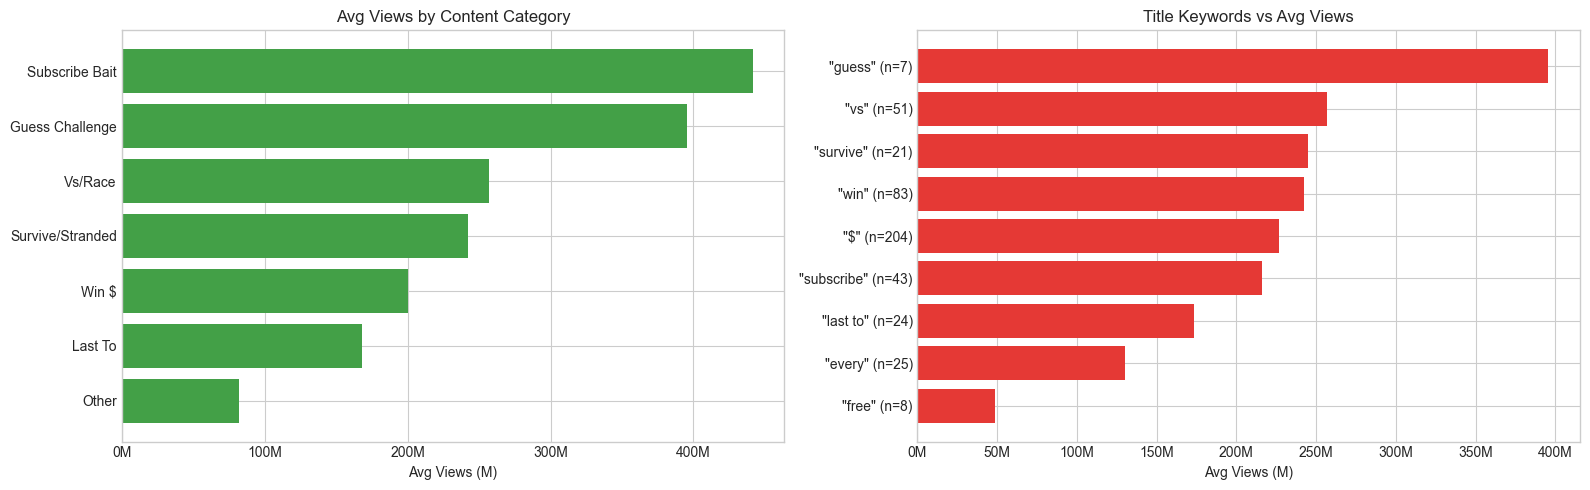

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avg views by category
ax = axes[0]
cat_avg = cat_stats['avg_views'].sort_values() / 1e6
ax.barh(cat_avg.index, cat_avg.values, color=GREEN)
ax.set_xlabel('Avg Views (M)')
ax.set_title('Avg Views by Content Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Title keywords vs avg views
ax = axes[1]
keywords = ['$', 'win', 'subscribe', 'survive', 'last to', 'vs', 'guess', 'free', 'every']
rows = []
for kw in keywords:
    mask = df['title'].str.lower().str.contains(kw, regex=False)
    if mask.sum() >= 3:
        rows.append({'keyword': f'"{kw}" (n={mask.sum()})',
                     'avg_views': df[mask]['view_count'].mean() / 1e6})
kw_df = pd.DataFrame(rows).sort_values('avg_views')
ax.barh(kw_df['keyword'], kw_df['avg_views'], color=RED)
ax.set_xlabel('Avg Views (M)')
ax.set_title('Title Keywords vs Avg Views')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.show()

## 6. Key Findings

| Finding | Detail |
|---------|--------|
| **Growth inflection** | Views per video surged around 2019 and peaked 2022–2024 |
| **Short-form dominates velocity** | Short videos (<2 min) average 2–3× more views/day than long-form |
| **Long-form drives engagement** | Long videos have higher engagement rate — viewers who watch are more invested |
| **Subscribe Bait tops avg views** | Videos prompting subscription in exchange for a reward average the highest views |
| **Engagement has declined** | As the channel scaled, engagement rate dropped from ~10% (2017) to ~2% (2025) — typical for mega-channels |
| **Duration collapsed post-2023** | Median video length dropped from 10–15 min to under 1 min, mirroring YouTube Shorts trend |
| **"guess" and "vs" keywords** | Titles with these words consistently outperform average |

---
*Data source: YouTube Data API v3 | Channel: MrBeast (UCX6OQ3DkcsbYNE6H8uQQuVA)*